In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

DATA_DIR = Path("../data")
DIVVY_RAW = DATA_DIR / "raw" / "divvy"
WEATHER_RAW = DATA_DIR / "raw" / "weather"
REFERENCE_DIR = DATA_DIR / "reference"

REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

print(DIVVY_RAW.exists())
print(sorted(DIVVY_RAW.glob("*.parquet"))[:3])

True
[PosixPath('../data/raw/divvy/2023-07.parquet'), PosixPath('../data/raw/divvy/2023-08.parquet'), PosixPath('../data/raw/divvy/2023-09.parquet')]


In [2]:
trips = pl.scan_parquet(str(DIVVY_RAW / "*.parquet"))

schema = trips.collect_schema()
schema

Schema([('ride_id', String),
        ('rideable_type', String),
        ('started_at', Datetime(time_unit='us', time_zone=None)),
        ('ended_at', Datetime(time_unit='us', time_zone=None)),
        ('start_station_name', String),
        ('start_station_id', String),
        ('end_station_name', String),
        ('end_station_id', String),
        ('start_lat', Float64),
        ('start_lng', Float64),
        ('end_lat', Float64),
        ('end_lng', Float64),
        ('member_casual', String)])

## 1. Data overview

In [3]:
overview = trips.select(
    pl.len().alias("total_trips"),
    pl.col("started_at").min().alias("min_started_at"),
    pl.col("started_at").max().alias("max_started_at"),
    pl.col("start_station_id").n_unique().alias("n_start_station_ids"),
    pl.col("end_station_id").n_unique().alias("n_end_station_ids"),
).collect()

overview

total_trips,min_started_at,max_started_at,n_start_station_ids,n_end_station_ids
u32,datetime[μs],datetime[μs],u32,u32
16501210,2023-07-01 00:00:00,2026-05-31 23:57:08,3813,3843


#### Conclusion
The raw Divvy dataset contains 16,501,210 trips from 2023-07-01 to 2026-05-31, with 3,813 distinct start station IDs and 3,843 distinct end station IDs.

## 2. Monthly demand

In [11]:
monthly = (
    trips
    .with_columns(pl.col("started_at").dt.strftime("%Y-%m").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("trips"))
    .sort("month")
    .collect()
)

monthly

month,trips
str,u32
"""2023-07""",767650
"""2023-08""",771693
"""2023-09""",666371
"""2023-10""",537113
"""2023-11""",362518
…,…
"""2026-01""",137782
"""2026-02""",201454
"""2026-03""",317015


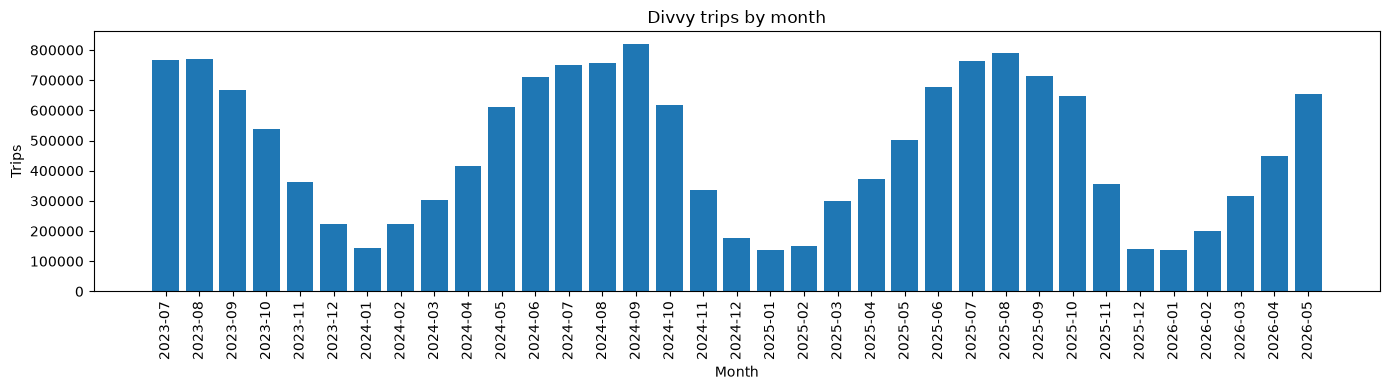

(shape: (1, 2)
 ┌─────────┬────────┐
 │ month   ┆ trips  │
 │ ---     ┆ ---    │
 │ str     ┆ u32    │
 ╞═════════╪════════╡
 │ 2024-09 ┆ 820867 │
 └─────────┴────────┘,
 shape: (1, 2)
 ┌─────────┬────────┐
 │ month   ┆ trips  │
 │ ---     ┆ ---    │
 │ str     ┆ u32    │
 ╞═════════╪════════╡
 │ 2026-01 ┆ 137782 │
 └─────────┴────────┘)

In [8]:
monthly_pd = monthly.to_pandas()

plt.figure(figsize=(14, 4))
plt.bar(monthly_pd["month"], monthly_pd["trips"])
plt.xticks(rotation=90)
plt.title("Divvy trips by month")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()


max_month = monthly.sort("trips", descending=True).head(1)
min_month = monthly.sort("trips").head(1)
max_month, min_month

#### Conclusion: 
Monthly Divvy demand shows clear seasonality. The highest-demand month is September 2024 with 820,867 trips, while the lowest-demand month is January 2026 with 137,782 trips. Peak monthly demand is about 6.0 times higher than the winter low, so the training window must cover a full annual cycle rather than only recent months.

## 2.Data Quality

In [9]:

quality_base = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds"),
        pl.col("start_station_id").is_null().alias("missing_start_station_id"),
        pl.col("end_station_id").is_null().alias("missing_end_station_id"),
        (pl.col("started_at") > pl.col("ended_at")).alias("started_after_ended"),
    )
    .select(
        pl.len().alias("total"),
        (pl.col("duration_seconds") < 60).sum().alias("duration_lt_60s"),
        (pl.col("duration_seconds") > 24 * 3600).sum().alias("duration_gt_24h"),
        pl.col("missing_start_station_id").sum().alias("missing_start_station_id"),
        pl.col("missing_end_station_id").sum().alias("missing_end_station_id"),
        pl.col("started_after_ended").sum().alias("started_after_ended"),
    )
    .collect()
)

quality_base

total,duration_lt_60s,duration_gt_24h,missing_start_station_id,missing_end_station_id,started_after_ended
u32,u32,u32,u32,u32,u32
16501210,401054,18993,3120590,3257603,506


In [10]:
q = quality_base.to_pandas().iloc[0]
total = q["total"]

quality_summary = pd.DataFrame(
    {
        "rule": [
            "duration < 60s",
            "duration > 24h",
            "missing start_station_id",
            "missing end_station_id",
            "started_at > ended_at",
        ],
        "rows": [
            q["duration_lt_60s"],
            q["duration_gt_24h"],
            q["missing_start_station_id"],
            q["missing_end_station_id"],
            q["started_after_ended"],
        ],
    }
)

quality_summary["pct"] = quality_summary["rows"] / total * 100
quality_summary

,rule,rows,pct
0,duration < 60s,401054,2.430452
1,duration > 24h,18993,0.115101
2,missing start_station_id,3120590,18.911280
3,missing end_station_id,3257603,19.741601
4,started_at > ended_at,506,0.003066


#### Conclusion

Conclusion: The largest station-level data quality issue is missing station IDs. Missing `start_station_id` affects 3,120,590 trips, or 18.91% of all trips, while missing `end_station_id` affects 3,257,603 trips, or 19.74%. These trips are valid system-level trips, but they cannot be assigned reliably to a specific station, so trips with missing `start_station_id` will be excluded from station-level demand modeling.

Very short trips are also non-trivial: 401,054 trips, or 2.43%, have duration below 60 seconds. Trips longer than 24 hours are rare at 18,993 trips, or 0.12%, and trips where `started_at > ended_at` are negligible at 506 trips, or 0.003%.

## 3. Trip Duration

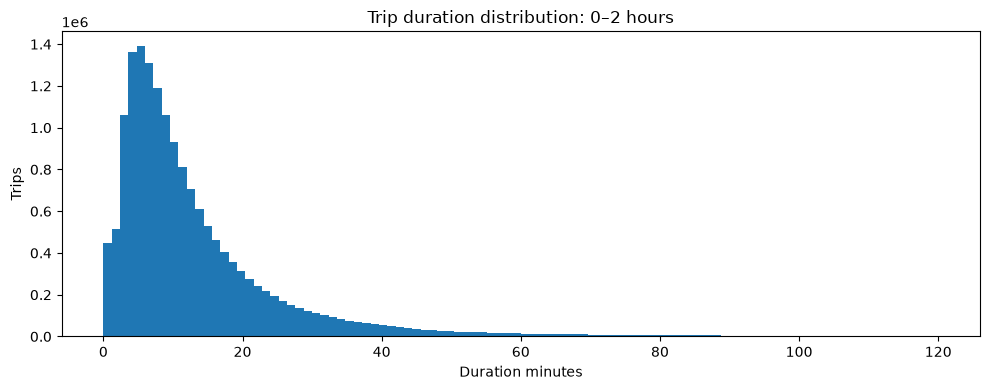

In [13]:
durations = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds")
    )
    .filter(pl.col("duration_seconds").is_between(0, 2 * 3600))
    .select("duration_seconds")
    .collect()
)

durations_pd = durations.to_pandas()

plt.figure(figsize=(10, 4))
plt.hist(durations_pd["duration_seconds"] / 60, bins=100)
plt.title("Trip duration distribution: 0–2 hours")
plt.xlabel("Duration minutes")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()

#### Conclusion: 
The 60-second and 24-hour thresholds are reasonable initial cleaning rules. Trips under 60 seconds are likely immediate re-docks, tests, or recording errors, while trips over 24 hours are likely extreme outliers or bikes that were not properly returned.

In [14]:
clean_trips = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds")
    )
    .filter(pl.col("duration_seconds") >= 60)
    .filter(pl.col("duration_seconds") <= 24 * 3600)
    .filter(pl.col("start_station_id").is_not_null())
    .filter(pl.col("started_at") <= pl.col("ended_at"))
)

clean_overview = clean_trips.select(
    pl.len().alias("clean_trips"),
    pl.col("start_station_id").n_unique().alias("clean_start_station_ids"),
).collect()

clean_overview

clean_trips,clean_start_station_ids
u32,u32
13166874,3786


#### Temporary cleaned trip view

Conclusion: After applying the initial station-level cleaning rules, the dataset retains 13,166,874 trips and 3,786 distinct start station IDs. This cleaned view removes trips with unreliable station assignment or extreme durations, while preserving the majority of usable demand records for station-level EDA.

## 4. Station quality

In [17]:
station_table = (
    clean_trips
    .with_columns(pl.col("started_at").dt.strftime("%Y-%m").alias("month"))
    .group_by("start_station_id")
    .agg(
        pl.col("start_station_name").drop_nulls().mode().first().alias("station_name"),
        pl.col("start_lat").median().alias("lat"),
        pl.col("start_lng").median().alias("lng"),
        pl.col("month").min().alias("first_month"),
        pl.col("month").max().alias("last_month"),
        pl.len().alias("total_trips"),
    )
    .sort("total_trips", descending=True)
    .collect()
)

station_table.head(20)
station_table.shape

(3786, 7)

#### Conclusion
After cleaning, the dataset contains 3,786 distinct start station IDs. The station table summarizes each station by its most common name, median coordinates, first and last observed month, and total trip volume. This table will be used as the basis for station mapping and for selecting the final top-N station scope.

In [18]:
station_coord_quality = station_table.select(
    pl.len().alias("stations"),
    pl.col("lat").is_null().sum().alias("missing_lat"),
    pl.col("lng").is_null().sum().alias("missing_lng"),
    ((pl.col("lat") < 41.0) | (pl.col("lat") > 43.0)).sum().alias("lat_outside_chicago_area"),
    ((pl.col("lng") < -89.0) | (pl.col("lng") > -87.0)).sum().alias("lng_outside_chicago_area"),
)

station_coord_quality


stations,missing_lat,missing_lng,lat_outside_chicago_area,lng_outside_chicago_area
u32,u32,u32,u32,u32
3786,0,0,0,0


#### Conclusion:
Station coordinate quality is sufficient for the initial mapping step. Median latitude and longitude are used for each station to reduce the effect of GPS noise and occasional coordinate outliers. Stations with missing or clearly invalid coordinates should be reviewed separately, but they do not block the first-pass station-level EDA.

## Duplicate station candidates

In [19]:
import numpy as np
from itertools import product


def haversine_m(lat1, lng1, lat2, lng2):
    radius = 6_371_000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lng2 - lng1)

    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    )
    return 2 * radius * np.arcsin(np.sqrt(a))


stations_pd = station_table.drop_nulls(["lat", "lng"]).to_pandas()

stations_pd["lat_bin"] = (stations_pd["lat"] * 1000).astype(int)
stations_pd["lng_bin"] = (stations_pd["lng"] * 1000).astype(int)

bins = {}
for i, row in stations_pd.iterrows():
    bins.setdefault((row["lat_bin"], row["lng_bin"]), []).append(i)

pairs = []

for (lat_bin, lng_bin), idxs in bins.items():
    candidate_idxs = []
    for dlat, dlng in product([-1, 0, 1], repeat=2):
        candidate_idxs.extend(bins.get((lat_bin + dlat, lng_bin + dlng), []))

    for i in idxs:
        for j in candidate_idxs:
            if j <= i:
                continue

            a = stations_pd.loc[i]
            b = stations_pd.loc[j]
            dist = haversine_m(a["lat"], a["lng"], b["lat"], b["lng"])

            if dist < 30:
                pairs.append(
                    {
                        "id_a": a["start_station_id"],
                        "name_a": a["station_name"],
                        "trips_a": a["total_trips"],
                        "id_b": b["start_station_id"],
                        "name_b": b["station_name"],
                        "trips_b": b["total_trips"],
                        "dist_m": round(dist, 1),
                    }
                )

suspects = pl.DataFrame(pairs).sort("dist_m")
suspects.head(50)

id_a,name_a,trips_a,id_b,name_b,trips_b,dist_m
str,str,i64,str,str,i64,f64
"""13022""","""Streeter Dr & Grand Ave""",113726,"""CHI01747""","""Navy Pier""",68328,0.0
"""PI00002""","""Streeter Dr/Grand Ave""",9505,"""CHI00588""","""Streeter Dr/Grand Ave""",2078,0.0
"""13300""","""DuSable Lake Shore Dr & Monroe…",75346,"""CHI00374""","""DuSable Lake Shore Dr & Monroe…",40785,0.0
"""KA1503000043""","""Kingsbury St & Kinzie St""",71914,"""CHI00299""","""Kingsbury St & Kinzie St""",34676,0.0
"""13042""","""Michigan Ave & Oak St""",67640,"""CHI00252""","""Michigan Ave & Oak St""",36082,0.0
…,…,…,…,…,…,…
"""TA1309000039""","""DuSable Lake Shore Dr & Divers…",37554,"""CHI00493""","""DuSable Lake Shore Dr & Divers…",18970,0.0
"""TA1305000022""","""Orleans St & Merchandise Mart …",37097,"""CHI00367""","""Orleans St & Merchandise Mart …",20076,0.0
"""13325""","""Broadway & Waveland Ave""",37021,"""CHI00496""","""Broadway & Waveland Ave""",18993,0.0


#### Conclusion:
There are 2152 pairs of station IDs within 30 meters of each other. These pairs are potential duplicate stations or nearby docks that may represent the same physical station across different IDs. As this time, only obvious duplicates should be mapped, while ambiguous cases should be left unchanged to avoid over-engineering the station mapping step.

In [28]:
station_mapping = station_table.select(
    pl.col("start_station_id").alias("raw_station_id"),
    pl.col("start_station_id").alias("canonical_station_id"),
)

station_mapping.write_csv(REFERENCE_DIR / "station_mapping.csv")

station_mapping.head()

raw_station_id,canonical_station_id
str,str
"""13022""","""13022"""
"""13300""","""13300"""
"""KA1503000043""","""KA1503000043"""
"""CHI01747""","""CHI01747"""
"""13042""","""13042"""


## Normalize mapping 

In [21]:
def normalize_name(name):
    if name is None:
        return ""
    return "".join(str(name).lower().replace("&", "and").split())


if suspects.height > 0:
    suspects_with_norm = suspects.with_columns(
        pl.col("name_a").map_elements(normalize_name, return_dtype=pl.Utf8).alias("name_a_norm"),
        pl.col("name_b").map_elements(normalize_name, return_dtype=pl.Utf8).alias("name_b_norm"),
    )

    obvious_duplicates = suspects_with_norm.filter(
        pl.col("name_a_norm") == pl.col("name_b_norm")
    )

    obvious_duplicates.head(30)
else:
    obvious_duplicates = pl.DataFrame()

In [22]:
if obvious_duplicates.height > 0:
    duplicate_mapping = obvious_duplicates.select(
        pl.when(pl.col("trips_a") >= pl.col("trips_b"))
        .then(pl.col("id_b"))
        .otherwise(pl.col("id_a"))
        .alias("raw_station_id"),
        pl.when(pl.col("trips_a") >= pl.col("trips_b"))
        .then(pl.col("id_a"))
        .otherwise(pl.col("id_b"))
        .alias("canonical_station_id"),
    )

    station_mapping = (
        station_mapping
        .join(duplicate_mapping, on="raw_station_id", how="left", suffix="_dup")
        .with_columns(
            pl.coalesce(
                pl.col("canonical_station_id_dup"),
                pl.col("canonical_station_id"),
            ).alias("canonical_station_id")
        )
        .select(["raw_station_id", "canonical_station_id"])
    )

    station_mapping.write_csv(REFERENCE_DIR / "station_mapping.csv")

station_mapping.head()

raw_station_id,canonical_station_id
str,str
"""13022""","""13022"""
"""13300""","""13300"""
"""KA1503000043""","""KA1503000043"""
"""CHI01747""","""CHI01747"""
"""13042""","""13042"""


In [25]:
suspects.shape

(2152, 7)

## Reference data export

Conclusion: The station mapping was exported to `data/reference/station_mapping.csv`. Unlike downloaded raw trip data, this file is project-specific reference data and should be committed to Git because it records modeling decisions that are not directly available from the raw source files.